# 예제1
Atlanta, Chicago, Cincinnati, Houston, LA, Montreal 6 개 도시간 거리 정보가 다음과 같을 때 TSP 문제를 푸시오

In [4]:
from ortools.linear_solver import pywraplp

nCity = 6

DIST = [ [0, 702, 454, 842, 2396, 1196],
        [702, 0, 324, 1093, 2136, 764],
        [454, 324, 0, 1137, 2180, 798],
        [842, 1093, 1137, 0, 1616, 1857],
        [2396, 2136, 2180, 1616, 0, 2900],
        [1196, 764, 798, 1857, 2900, 0]
]

solver = pywraplp.Solver.CreateSolver('SAT')

X = {}
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            X[i, j] = solver.IntVar(0, 1, 'X[%i,%i]' % (i, j))

U = {}
for i in range(nCity):
    U[i] = solver.IntVar(0, nCity - 1, 'U[%i]' % i)

# 제약조건
# 도시 j로 한 번은 들어와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[i, j] for i in range(nCity) if i != j]) == 1, 'in_'+str(i))    

# 도시 j로부터 한 번은 나와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[j, i] for i in range(nCity) if i != j]) == 1, 'out_'+str(i))   

# 방문 순서 제약
for i in range(1, nCity):
    for j in range(1, nCity):
        if i != j:
            solver.Add(U[i] - U[j] + 1 - (nCity-1) * (1-X[i, j]) <= 0, 'U_'+str(i)+str(j))

# Objective
objective_terms = []
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            objective_terms.append(DIST[i][j] * X[i, j])
solver.Minimize(solver.Sum(objective_terms))

if 1:
    with open('or7-1.lp', 'w') as out_f:
        lp_text = solver.ExportModelAsLpFormat(False)
        out_f.write(lp_text)

# Solve
status = solver.Solve()

# Print solution.
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"Total cost = {solver.Objective().Value():.1f}\n",)
    for i in range(nCity):
        for j in range(nCity):
            if i != j:
                if X[i, j].solution_value() > 0.5:
                    print(f"X{i} --> X{j}")
    for i in range(nCity):
        print(f"{i} 도시 방문 순서:", U[i].solution_value())
    else:    
        print('No solution found.')

Total cost = 6610.0

X0 --> X2
X1 --> X4
X2 --> X5
X3 --> X0
X4 --> X3
X5 --> X1
0 도시 방문 순서: 5.0
1 도시 방문 순서: 2.0
2 도시 방문 순서: 0.0
3 도시 방문 순서: 4.0
4 도시 방문 순서: 3.0
5 도시 방문 순서: 1.0
No solution found.


# 실습1

In [ ]:
import pandas as pd

df = pd.read_excel ('./tsp_ex_data1.xlsx', index_col = 'Unnamed: 0')
DIST = df.values.tolist()

## TSP with 12 cities
from ortools.linear_solver import pywraplp

nCity = 12

solver = pywraplp.Solver.CreateSolver('SAT')

X = {}
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            X[i, j] = solver.IntVar(0, 1, 'X[%i,%i]' % (i, j))

U = {}
for i in range(nCity):
    U[i] = solver.IntVar(0, nCity - 1, 'U[%i]' % i)

# 제약조건
# 도시 j로 한 번은 들어와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[i, j] for i in range(nCity) if i != j]) == 1, 'in_'+str(i))    

# 도시 j로부터 한 번은 나와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[j, i] for i in range(nCity) if i != j]) == 1, 'out_'+str(i))   

# 방문 순서 제약
for i in range(1, nCity):
    for j in range(1, nCity):
        if i != j:
            solver.Add(U[i] - U[j] + 1 - (nCity-1) * (1-X[i, j]) <= 0, 'U_'+str(i)+str(j))

# Objective
objective_terms = []
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            objective_terms.append(DIST[i][j] * X[i, j])
solver.Minimize(solver.Sum(objective_terms))

if 1:
    with open('or7-1.lp', 'w') as out_f:
        lp_text = solver.ExportModelAsLpFormat(False)
        out_f.write(lp_text)

# Solve
status = solver.Solve()

# Print solution.
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"Total cost = {solver.Objective().Value():.1f}\n",)
    for i in range(nCity):
        for j in range(nCity):
            if i != j:
                if X[i, j].solution_value() > 0.5:
                    print(f"X{i} --> X{j}")
    for i in range(nCity):
        print(f"{i} 도시 방문 순서:", U[i].solution_value())
    else:    
        print('No solution found.')

Total cost = 7577.0

X0 --> X3
X1 --> X5
X2 --> X0
X3 --> X10
X4 --> X11
X5 --> X6
X6 --> X7
X7 --> X8
X8 --> X2
X9 --> X1
X10 --> X4
X11 --> X9
0 도시 방문 순서: 11.0
1 도시 방문 순서: 6.0
2 도시 방문 순서: 11.0
3 도시 방문 순서: 1.0
4 도시 방문 순서: 3.0
5 도시 방문 순서: 7.0
6 도시 방문 순서: 8.0
7 도시 방문 순서: 9.0
8 도시 방문 순서: 10.0
9 도시 방문 순서: 5.0
10 도시 방문 순서: 2.0
11 도시 방문 순서: 4.0
No solution found.


# 실습 2 - TSP_LIB 파일 읽어 TSP 문제 만들기

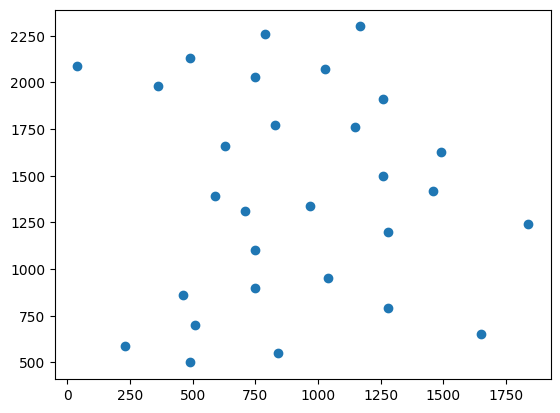

In [7]:
from ortools.linear_solver import pywraplp
import pandas as pd
import math
import matplotlib.pyplot as plt

def calDist(x1, y1, x2, y2):

    dist = math.sqrt((x1-x2)**2+(y1-y2)**2)

    return dist

def makeDIST(nP):

    DIST = list()
    nCity = len(nP)

    for i in range(nCity):
        DIST.append([])
        for j in range(nCity):
            if j != i:
                temp = calDist(nP['xc'][i], nP['yc'][i], nP['xc'][j], nP['yc'][j])
                DIST[i].append(temp)
            else:
                DIST[i].append(0)
    
    return DIST

#%% MAIN FLOW
nPos = pd.DataFrame(columns=['xc', 'yc'])

f = open("./TSP_data/bays29.tsp", 'r')
#f = open(".\\Tsp_data\\berlin52.tsp", 'r')

flag = 0

while True:
    line = f.readline().strip()

    if not line: break

    if line == "NODE_COORD_SECTION" or line == "DISPLAY_DATA_SECTION":
        flag = 1
        continue

    if line == "EOF":
        continue

    if flag:
        ss = line.split()
        nPos.loc[len(nPos)] = [float(ss[1]), float(ss[2])]

DIST = makeDIST(nPos)
# print(DIST)

f.close()

#%%
plt.scatter(nPos['xc'], nPos['yc'])
plt.show()



In [8]:
from ortools.linear_solver import pywraplp

nCity = len(DIST)

solver = pywraplp.Solver.CreateSolver('SAT')

X = {}
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            X[i, j] = solver.IntVar(0, 1, 'X[%i,%i]' % (i, j))

U = {}
for i in range(nCity):
    U[i] = solver.IntVar(0, nCity - 1, 'U[%i]' % i)

# 제약조건
# 도시 j로 한 번은 들어와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[i, j] for i in range(nCity) if i != j]) == 1, 'in_'+str(i))    

# 도시 j로부터 한 번은 나와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[j, i] for i in range(nCity) if i != j]) == 1, 'out_'+str(i))   

# 방문 순서 제약
for i in range(1, nCity):
    for j in range(1, nCity):
        if i != j:
            solver.Add(U[i] - U[j] + 1 - (nCity-1) * (1-X[i, j]) <= 0, 'U_'+str(i)+str(j))

# Objective
objective_terms = []
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            objective_terms.append(DIST[i][j] * X[i, j])
solver.Minimize(solver.Sum(objective_terms))

if 1:
    with open('or7-1.lp', 'w') as out_f:
        lp_text = solver.ExportModelAsLpFormat(False)
        out_f.write(lp_text)

# Solve
status = solver.Solve()

# Print solution.
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"Total cost = {solver.Objective().Value():.1f}\n",)
    for i in range(nCity):
        for j in range(nCity):
            if i != j:
                if X[i, j].solution_value() > 0.5:
                    print(f"X{i} --> X{j}")
    for i in range(nCity):
        print(f"{i} 도시 방문 순서:", U[i].solution_value())
    else:    
        print('No solution found.')

Total cost = 9074.1

X0 --> X23
X1 --> X20
X2 --> X25
X3 --> X9
X4 --> X28
X5 --> X27
X6 --> X24
X7 --> X22
X8 --> X11
X9 --> X19
X10 --> X21
X11 --> X5
X12 --> X15
X13 --> X17
X14 --> X3
X15 --> X26
X16 --> X13
X17 --> X14
X18 --> X10
X19 --> X1
X20 --> X4
X21 --> X16
X22 --> X6
X23 --> X12
X24 --> X18
X25 --> X8
X26 --> X7
X27 --> X0
X28 --> X2
0 도시 방문 순서: 28.0
1 도시 방문 순서: 18.0
2 도시 방문 순서: 22.0
3 도시 방문 순서: 15.0
4 도시 방문 순서: 20.0
5 도시 방문 순서: 26.0
6 도시 방문 순서: 6.0
7 도시 방문 순서: 4.0
8 도시 방문 순서: 24.0
9 도시 방문 순서: 16.0
10 도시 방문 순서: 9.0
11 도시 방문 순서: 25.0
12 도시 방문 순서: 1.0
13 도시 방문 순서: 12.0
14 도시 방문 순서: 14.0
15 도시 방문 순서: 2.0
16 도시 방문 순서: 11.0
17 도시 방문 순서: 13.0
18 도시 방문 순서: 8.0
19 도시 방문 순서: 17.0
20 도시 방문 순서: 19.0
21 도시 방문 순서: 10.0
22 도시 방문 순서: 5.0
23 도시 방문 순서: 0.0
24 도시 방문 순서: 7.0
25 도시 방문 순서: 23.0
26 도시 방문 순서: 3.0
27 도시 방문 순서: 27.0
28 도시 방문 순서: 21.0
No solution found.


# 실습3

In [ ]:
from ortools.linear_solver import pywraplp
import pandas as pd

df = pd.read_excel('./tsp_ex_data1.xlsx', index_col='Unnamed: 0')
DIST = df.values.tolist()

profits = profits = [35000, 13000,
                     58000, 41000, 13000, 54000,
                     65000, 48000, 69000, 56000,
                     34000, 67000 ]
nCity = 12
N_visit = 6

solver = pywraplp.Solver.CreateSolver('SCIP')

X = {}
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            X[i, j] = solver.IntVar(0, 1, f'X[{i},{j}]')

Y = {}
for i in range(nCity):
    Y[i] = solver.IntVar(0, 1, f'Y[{i}]')

U = {}
for i in range(nCity):
    U[i] = solver.IntVar(0, nCity - 1, f'U[{i}]')

# 시작 도시 고정
solver.Add(Y[2] == 1)

# 방문한 도시만 들어오고 나가도록
for j in range(nCity):
    solver.Add(solver.Sum(X[i, j] for i in range(nCity) if i != j) == Y[j], f'in_{j}')

for i in range(nCity):
    solver.Add(solver.Sum(X[i, j] for j in range(nCity) if i != j) == Y[i], f'out_{i}')

# 정확히 N개 방문
solver.Add(solver.Sum(Y[i] for i in range(nCity)) == N_visit, 'visit_n_city')

# MTZ
depot = 2

for i in range(nCity):
    if i == depot:
        continue
    for j in range(nCity):
        if j == depot or i == j:
            continue
        solver.Add(U[i] - U[j] + 1 - (nCity-1) * (1 - X[i, j]) <= 0)

# 목적함수
objective_terms = []
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            objective_terms.append(DIST[i][j] * X[i, j])

for i in range(nCity):
    objective_terms.append(-profits[i] * Y[i])

solver.Minimize(solver.Sum(objective_terms))

status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"Total cost = {solver.Objective().Value():.1f}")
    for i in range(nCity):
        print(f"Y[{i}] =", Y[i].solution_value())
    for i in range(nCity):
        for j in range(nCity):
            if i != j and X[i, j].solution_value() > 0.5:
                print(f"{i} --> {j}")
else:
    print("No solution found.")

Total cost = -362520.0
Y[0] = 0.0
Y[1] = 0.0
Y[2] = 1.0
Y[3] = 0.0
Y[4] = 0.0
Y[5] = 1.0
Y[6] = 1.0
Y[7] = 0.0
Y[8] = 1.0
Y[9] = 1.0
Y[10] = 0.0
Y[11] = 1.0
2 --> 8
5 --> 11
6 --> 5
8 --> 6
9 --> 2
11 --> 9


# Tsp_data /berlin52.tsp 에 대한 TSP 최적화 python 프로그램을 작성

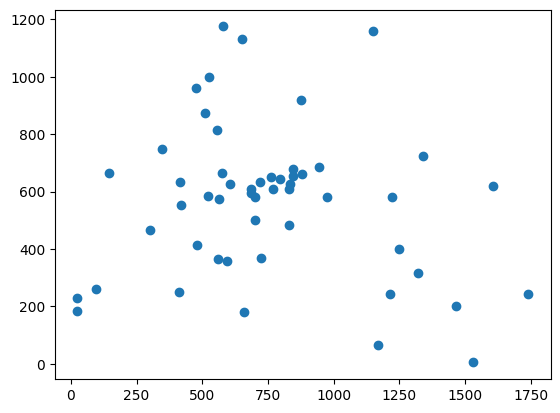

In [ ]:
from ortools.linear_solver import pywraplp
import pandas as pd
import math
import matplotlib.pyplot as plt

def calDist(x1, y1, x2, y2):

    dist = math.sqrt((x1-x2)**2+(y1-y2)**2)

    return dist

def makeDIST(nP):

    DIST = list()
    nCity = len(nP)

    for i in range(nCity):
        DIST.append([])
        for j in range(nCity):
            if j != i:
                temp = calDist(nP['xc'][i], nP['yc'][i], nP['xc'][j], nP['yc'][j])
                DIST[i].append(temp)
            else:
                DIST[i].append(0)
    
    return DIST

#%% MAIN FLOW
nPos = pd.DataFrame(columns=['xc', 'yc'])

f = open("./TSP_data/berlin52.tsp", 'r')
#f = open(".\\Tsp_data\\berlin52.tsp", 'r')

flag = 0

while True:
    line = f.readline().strip()

    if not line: break

    if line == "NODE_COORD_SECTION" or line == "DISPLAY_DATA_SECTION":
        flag = 1
        continue

    if line == "EOF":
        continue

    if flag:
        ss = line.split()
        nPos.loc[len(nPos)] = [float(ss[1]), float(ss[2])]

DIST = makeDIST(nPos)
# print(DIST)

f.close()

#%%
plt.scatter(nPos['xc'], nPos['yc'])
plt.show()

from ortools.linear_solver import pywraplp

nCity = len(DIST)

solver = pywraplp.Solver.CreateSolver('SAT')

X = {}
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            X[i, j] = solver.IntVar(0, 1, 'X[%i,%i]' % (i, j))

U = {}
for i in range(nCity):
    U[i] = solver.IntVar(0, nCity - 1, 'U[%i]' % i)

# 제약조건
# 도시 j로 한 번은 들어와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[i, j] for i in range(nCity) if i != j]) == 1, 'in_'+str(i))    

# 도시 j로부터 한 번은 나와야 한다.
for j in range(nCity):
    solver.Add(solver.Sum([X[j, i] for i in range(nCity) if i != j]) == 1, 'out_'+str(i))   

# 방문 순서 제약
for i in range(1, nCity):
    for j in range(1, nCity):
        if i != j:
            solver.Add(U[i] - U[j] + 1 - (nCity-1) * (1-X[i, j]) <= 0, 'U_'+str(i)+str(j))

# Objective
objective_terms = []
for i in range(nCity):
    for j in range(nCity):
        if i != j:
            objective_terms.append(DIST[i][j] * X[i, j])
solver.Minimize(solver.Sum(objective_terms))

if 1:
    with open('or7-1.lp', 'w') as out_f:
        lp_text = solver.ExportModelAsLpFormat(False)
        out_f.write(lp_text)

# Solve
status = solver.Solve()

# Print solution.
if status == pywraplp.Solver.OPTIMAL or status == pywraplp.Solver.FEASIBLE:
    print(f"Total cost = {solver.Objective().Value():.1f}\n",)
    for i in range(nCity):
        for j in range(nCity):
            if i != j:
                if X[i, j].solution_value() > 0.5:
                    print(f"X{i} --> X{j}")
    for i in range(nCity):
        print(f"{i} 도시 방문 순서:", U[i].solution_value())
    else:    
        print('No solution found.')